# Welcome to Viewport
## A world dedicated for quick experiment and data visualization

In [1]:
from chunker import Chunker
from collector import Collector
from rag import Augmentor, Retriever, Judger

### Visualization on ChromaDB

In [2]:
import chromadb

chroma_client = chromadb.PersistentClient(path="./chroma_db")
collection = chroma_client.get_collection("policy_procedures")
data = collection.get( include=["embeddings", "metadatas", "documents"] )

len(data["documents"])

204

In [3]:
import numpy as np

emb = data["embeddings"]          # lista di liste
ids = data["ids"]
metas = data.get("metadatas", None)

X = np.array(emb, dtype=np.float32)
print("shape:", X.shape)          # (n_points, dim)


shape: (204, 384)


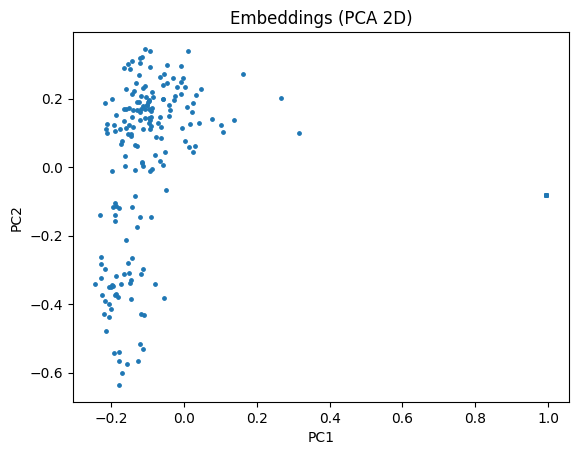

Explained variance ratio: [0.15998271 0.08121758]


In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(X)

plt.figure()
plt.scatter(X2[:,0], X2[:,1], s=6)
plt.title("Embeddings (PCA 2D)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


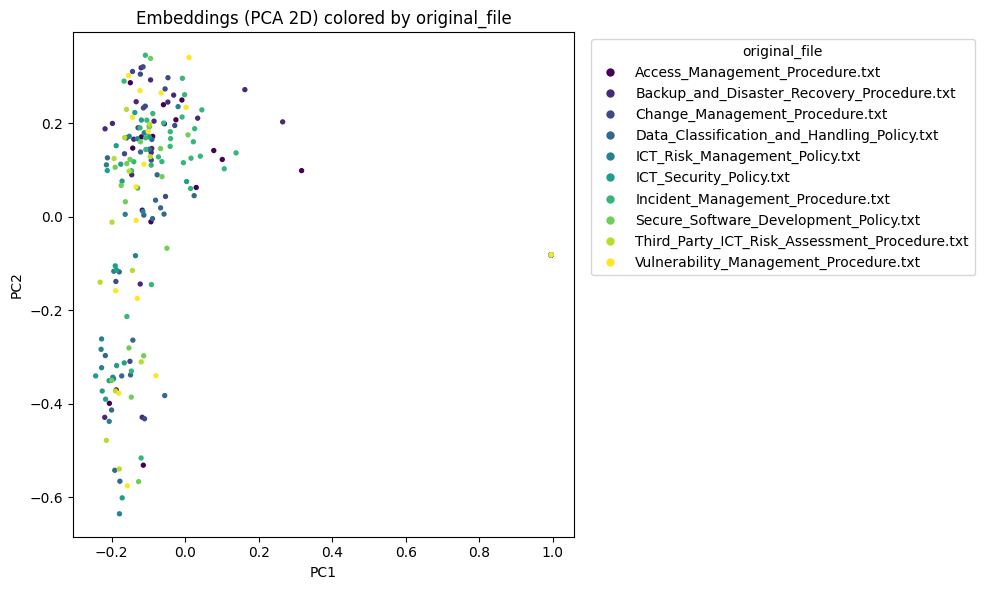

In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

key = "original_file"
labels = [m.get(key, "NA") if m else "NA" for m in metas]

uniq = {v:i for i,v in enumerate(sorted(set(labels)))}
c = np.array([uniq[v] for v in labels])

plt.figure(figsize=(10,6))
sc = plt.scatter(X2[:,0], X2[:,1], s=8, c=c)
plt.title(f"Embeddings (PCA 2D) colored by {key}")
plt.xlabel("PC1"); plt.ylabel("PC2")

# legenda
inv = {i:lab for lab,i in uniq.items()}  # int -> label
handles = [
    Line2D([0],[0], marker='o', linestyle='None',
           markersize=6,
           markerfacecolor=sc.cmap(sc.norm(i)),
           markeredgecolor='none',
           label=inv[i])
    for i in range(len(inv))
]
plt.legend(handles=handles, title=key, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



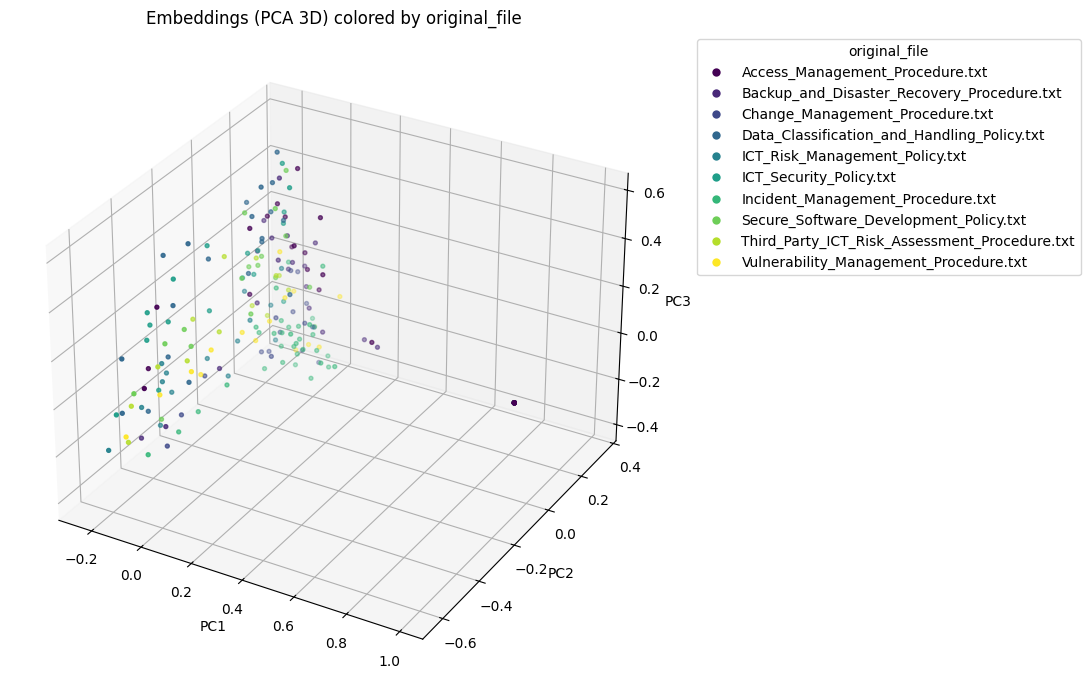

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# 1) Riduzione a 3D
pca3 = PCA(n_components=3, random_state=0)
X3 = pca3.fit_transform(X)   # X = embeddings (n, dim)

# 2) Colori per metadata
key = "original_file"
labels = [m.get(key, "NA") if m else "NA" for m in metas]

uniq = {v:i for i,v in enumerate(sorted(set(labels)))}
c = np.array([uniq[v] for v in labels])

# 3) Plot 3D
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(X3[:,0], X3[:,1], X3[:,2], s=8, c=c)
ax.set_title(f"Embeddings (PCA 3D) colored by {key}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")

# Legenda
inv = {i:lab for lab,i in uniq.items()}  # int -> label
handles = [
    Line2D([0],[0], marker='o', linestyle='None',
           markersize=6,
           markerfacecolor=sc.cmap(sc.norm(i)),
           markeredgecolor='none',
           label=inv[i])
    for i in range(len(inv))
]
ax.legend(handles=handles, title=key, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


### Cluster on ChromaDB

In [7]:
import numpy as np

X = np.array(data["embeddings"], dtype=np.float32)

# opzionale ma consigliato: normalizzazione L2 (≈ cosine)
Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = {}
for k in range(2, 16):
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels_k = km.fit_predict(Xn)
    scores[k] = silhouette_score(Xn, labels_k)

best_k = max(scores, key=scores.get)
best_k, scores[best_k]


(2, 0.24314387142658234)

In [11]:
km = KMeans(n_clusters=best_k, random_state=0, n_init="auto")
cluster = km.fit_predict(Xn)


In [12]:
import pandas as pd
pd.Series(cluster).value_counts().sort_index()


0    184
1     20
Name: count, dtype: int64

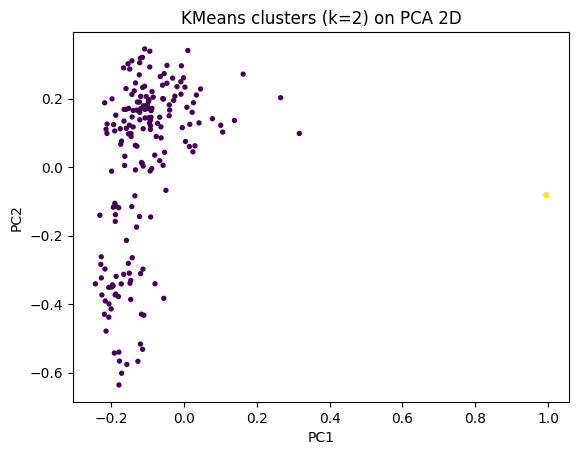

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X2[:,0], X2[:,1], s=8, c=cluster)
plt.title(f"KMeans clusters (k={best_k}) on PCA 2D")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


Capire cosa c'è in ogni cluster

In [14]:
key = "original_file"
files = [m.get(key, "NA") if m else "NA" for m in metas]

df = pd.DataFrame({"cluster": cluster, "file": files})

# per ogni cluster, i file più frequenti
for cl in sorted(df["cluster"].unique()):
    print("\nCluster", cl)
    display(df[df.cluster==cl]["file"].value_counts().head(10))



Cluster 0


file
Incident_Management_Procedure.txt                33
Data_Classification_and_Handling_Policy.txt      20
Backup_and_Disaster_Recovery_Procedure.txt       19
ICT_Security_Policy.txt                          18
Access_Management_Procedure.txt                  17
Secure_Software_Development_Policy.txt           17
ICT_Risk_Management_Policy.txt                   16
Change_Management_Procedure.txt                  16
Vulnerability_Management_Procedure.txt           15
Third_Party_ICT_Risk_Assessment_Procedure.txt    13
Name: count, dtype: int64


Cluster 1


file
Incident_Management_Procedure.txt              5
Access_Management_Procedure.txt                4
Backup_and_Disaster_Recovery_Procedure.txt     4
ICT_Risk_Management_Policy.txt                 2
Change_Management_Procedure.txt                1
Data_Classification_and_Handling_Policy.txt    1
ICT_Security_Policy.txt                        1
Secure_Software_Development_Policy.txt         1
Vulnerability_Management_Procedure.txt         1
Name: count, dtype: int64

In [16]:
docs = data["documents"]
centers = km.cluster_centers_

for cl in range(best_k):
    idx = np.where(cluster == cl)[0]
    # distanza al centro (su Xn)
    d = np.linalg.norm(Xn[idx] - centers[cl], axis=1)
    reps = idx[np.argsort(d)[:]]  # 3 esempi più centrali

    print(f"\n=== Cluster {cl} (n={len(idx)}) ===")
    for r in reps:
        print("FILE:", files[r], "| ID:", data["ids"][r])
        print(docs[r][:400].replace("\n"," "), "...\n")



=== Cluster 0 (n=184) ===
FILE: ICT_Security_Policy.txt | ID: 101
Information and Communication Technology (ICT) systems are critical assets for Corporate Banking Group (CBG). These systems enable customer onboarding, payments, lending operations, treasury services, regulatory reporting, and internal collaboration. The purpose of this ICT Security Policy is to define high-level principles and mandatory security rules for protecting information, systems, and serv ...

FILE: Third_Party_ICT_Risk_Assessment_Procedure.txt | ID: 182
Contracts for ICT third parties must include (as applicable): - Confidentiality and data protection obligations aligned to CBG classification. - Right to audit and/or access to independent assurance reports. - Incident and breach notification timelines and cooperation obligations. - Subcontractor controls and approval requirements. - Service levels, availability commitments, and support response t ...

FILE: ICT_Security_Policy.txt | ID: 102
The objectives of t

### Visual on Ret

,rank,id,distance,similarity,original_file,preview
0,1,18,0.429407,0.570593,Access_Management_Procedure.txt,Access must be revoked promptly when: - Employ...
1,2,11,0.505370,0.494630,Access_Management_Procedure.txt,1) Role changes must trigger access review and...
2,3,19,0.548394,0.451606,Access_Management_Procedure.txt,"Access requests, approvals, provisioning logs,..."
3,4,12,0.572932,0.427068,Access_Management_Procedure.txt,1) HR notifies termination date/time. For imme...
4,5,1,0.604821,0.395179,Access_Management_Procedure.txt,Access Management ensures that only authorized...
5,6,25,0.658400,0.341600,Backup_and_Disaster_Recovery_Procedure.txt,be restored after a disruption.
6,7,141,0.668442,0.331558,Incident_Management_Procedure.txt,1) Confirm the incident is not a standard serv...
7,8,2,0.672887,0.327113,Access_Management_Procedure.txt,This procedure applies to: - User accounts (em...
8,9,202,0.677020,0.322980,Vulnerability_Management_Procedure.txt,"Vulnerability tickets, evidence, exception app..."
9,10,80,0.698726,0.301274,Data_Classification_and_Handling_Policy.txt,Exceptions require Data Owner approval and Inf...


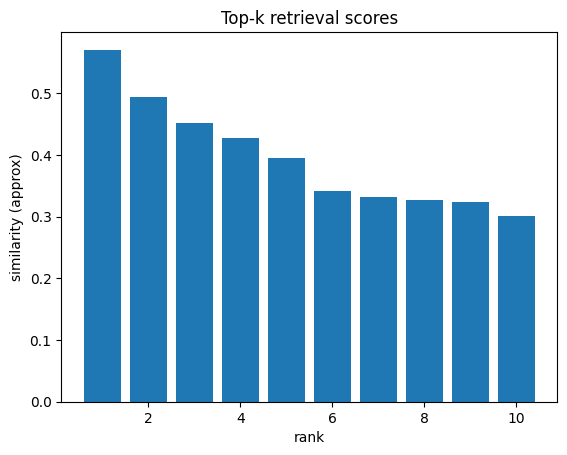

gap top1-top2: 0.07596254348754883


In [19]:
q = "access revoked employee leaves"
k = 10

res = collection.query(
    query_texts=[q],
    n_results=k,
    include=["documents","metadatas","distances"]
)

ids = res["ids"][0]
dist = np.array(res["distances"][0])
sim = 1 - dist  # spesso distance ~ (1 - cosine). Se usi altro spazio, non è sempre così.

df = pd.DataFrame({
    "rank": np.arange(1, k+1),
    "id": ids,
    "distance": dist,
    "similarity": sim,
    "original_file": [m.get("original_file","NA") for m in res["metadatas"][0]],
    "preview": [d[:140].replace("\n"," ") for d in res["documents"][0]],
})
display(df)

plt.figure()
plt.bar(df["rank"], df["similarity"])
plt.xlabel("rank"); plt.ylabel("similarity (approx)")
plt.title("Top-k retrieval scores")
plt.show()

print("gap top1-top2:", float(df.loc[0,"similarity"] - df.loc[1,"similarity"]))
